## Loading Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [19]:
from sklearn.model_selection import train_test_split

In [26]:
from sklearn.linear_model import LogisticRegression

## Data Loading

In [2]:
leads = pd.read_csv('data/Leads.csv')
leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


## Data Understanding

In [3]:
print("Shape of dataset:", leads.shape)

Shape of dataset: (9240, 37)


In [4]:
leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

In [34]:
leads.columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity',
       'Lead_Score'],
      dtype='str')

In [5]:
leads.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [6]:
leads.describe(include='string')

,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,...,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
count,9240,9240,9204,9240,9240,9137,6779,7802,7033,6550,...,4473,9240,9240,6531,7820,5022,5022,9240,9240,9240
unique,9240,5,21,2,2,17,38,19,10,6,...,5,1,1,6,7,3,3,1,2,16
top,7927b2df-8bba-4d29-b9a2-b6e0beafe620,Landing Page Submission,Google,No,No,Email Opened,India,Select,Select,Unemployed,...,Might be,No,No,Select,Mumbai,02.Medium,02.Medium,No,No,Modified
freq,1,4886,2868,8506,9238,3437,6492,1942,5043,5600,...,1560,9240,9240,4146,3222,3839,2788,9240,6352,3407


##  Missing Value Analysis

In [7]:
missing = pd.DataFrame({
    'Missing Count': leads.isnull().sum(),
    'Missing %': round(
        leads.isnull().sum()/len(leads)*100,2)
})

missing.sort_values(
    by='Missing %',
    ascending=False
).head(50)

,Missing Count,Missing %
Lead Quality,4767,51.59
Asymmetrique Profile Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Profile Score,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


## Data Cleaning

In [8]:
# Replace Select with NaN
leads = leads.replace('Select', np.nan)

# Missing percentage
missing = (
    leads.isnull().sum()/len(leads)
)*100

# Drop columns >40% missing
drop_cols = missing[missing > 40].index

leads = leads.drop(
    columns=drop_cols
)

print("Dropped Columns:")
print(drop_cols)

Dropped Columns:
Index(['How did you hear about X Education', 'Lead Quality', 'Lead Profile',
       'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
       'Asymmetrique Activity Score', 'Asymmetrique Profile Score'],
      dtype='str')


## Remove Identifiers

In [9]:
id_cols = [
    'Prospect ID',
    'Lead Number'
]

for col in id_cols:
    if col in leads.columns:
        leads.drop(
            col,
            axis=1,
            inplace=True
        )

## Missing Value Imputation

In [10]:
# Categorical columns
cat_cols = leads.select_dtypes(
    include=['object','string']
).columns

for col in cat_cols:
    leads[col] = leads[col].fillna(
        leads[col].mode()[0]
    )

# Numerical columns
num_cols = leads.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:
    leads[col] = leads[col].fillna(
        leads[col].median()
    )

## Verify Missing Values

In [11]:
print("Total Missing Values:",
      leads.isnull().sum().sum())

Total Missing Values: 0


## Create dummy variables

In [12]:
leads_encoded = pd.get_dummies(
    leads,
    drop_first=True
)

print(leads_encoded.shape)

(9240, 159)


## Duplicate Records

In [13]:
print("Duplicates:",
      leads.duplicated().sum())

leads.drop_duplicates(
    inplace=True
)

Duplicates: 1706


## EDA Expansion

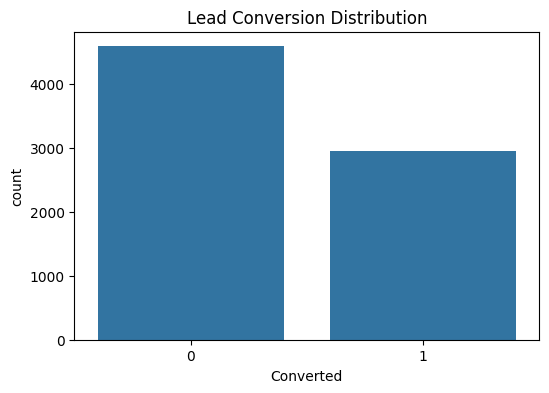

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Converted',
    data=leads
)

plt.title('Lead Conversion Distribution')
plt.show()

## Correlation Heatmap

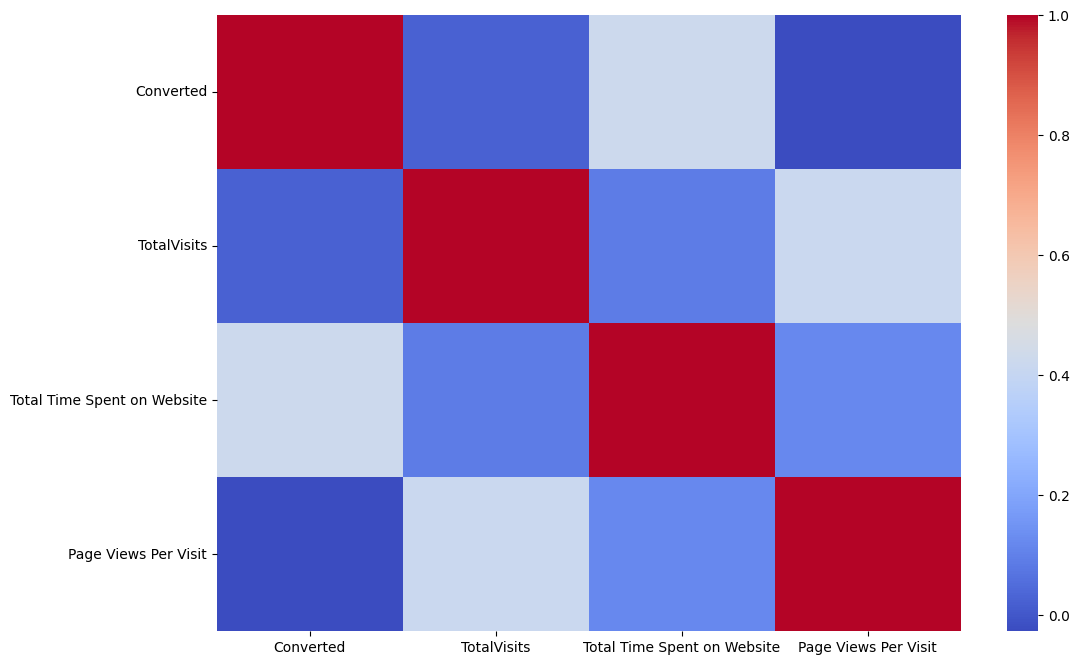

In [15]:
plt.figure(figsize=(12,8))

corr = leads.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

## Dummy Variables

In [16]:
leads_dum = pd.get_dummies(
    leads,
    drop_first=True
)

print(
    "Shape after encoding:",
    leads_dum.shape
)

Shape after encoding: (7534, 159)


## Train Test Split

In [20]:
X = leads_dum.drop('Converted', axis=1)
y = leads_dum['Converted']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=100,
    stratify=y
)

## Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

## Logistic Regression

In [27]:
model = LogisticRegression(
    max_iter=5000,
    random_state=100
)

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",100
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

## Evaluation

In [29]:
# Predicted class labels
y_pred = model.predict(X_test)

# Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

In [30]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

[[1248  126]
 [ 138  749]]
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1374
           1       0.86      0.84      0.85       887

    accuracy                           0.88      2261
   macro avg       0.88      0.88      0.88      2261
weighted avg       0.88      0.88      0.88      2261

Accuracy: 0.8832375055285272
ROC-AUC: 0.9479293334580525


## ROC Curve

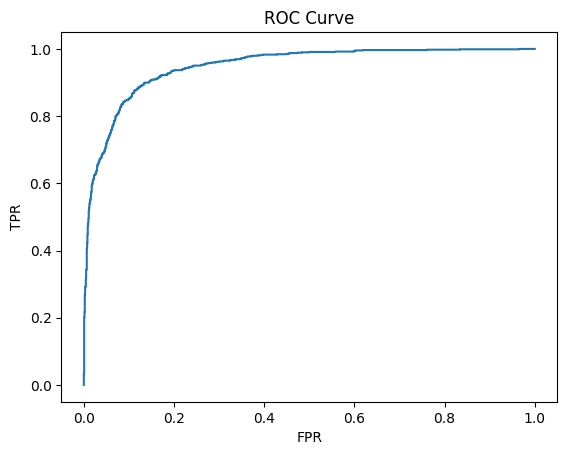

In [41]:
from sklearn.metrics import roc_curve

fpr,tpr,threshold = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr,tpr)

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.show()

## ROC Curve Visualization

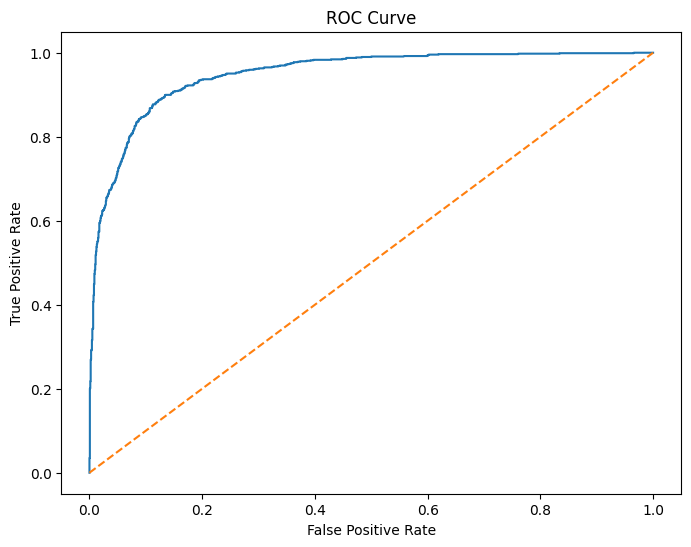

In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Feature Importance

In [36]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("Top Positive Features")
print(coef_df.head(10))

print("\nTop Negative Features")
print(coef_df.tail(10))

Top Positive Features
                                      Feature  Coefficient
130  Tags_Will revert after reading the email     2.005574
113                   Tags_Closed by Horizzon     1.706968
121                         Tags_Lost to EINS     1.166230
1                 Total Time Spent on Website     1.109640
4                   Lead Origin_Lead Add Form     0.785132
112                                 Tags_Busy     0.535171
154            Last Notable Activity_SMS Sent     0.483942
5                     Lead Origin_Lead Import     0.362550
118             Tags_Interested in Next batch     0.252554
12                     Lead Source_Olark Chat     0.250809

Top Negative Features
                                           Feature  Coefficient
151  Last Notable Activity_Olark Chat Conversation    -0.234200
38           Last Activity_Page Visited on Website    -0.244797
27                                Do Not Email_Yes    -0.278198
136                        Tags_wrong number given

## Top Variables

In [32]:
coef_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Coefficient':model.coef_[0]
})

coef_df['AbsCoef'] = abs(
    coef_df['Coefficient']
)

top_vars = coef_df.sort_values(
    'AbsCoef',
    ascending=False
)

top_vars.head(20)

,Feature,Coefficient,AbsCoef
130,Tags_Will revert after reading the email,2.005574,2.005574
113,Tags_Closed by Horizzon,1.706968,1.706968
121,Tags_Lost to EINS,1.166230,1.166230
1,Total Time Spent on Website,1.109640,1.109640
4,Lead Origin_Lead Add Form,0.785132,0.785132
150,Last Notable Activity_Modified,-0.783204,0.783204
102,What is your current occupation_Unemployed,-0.599792,0.599792
112,Tags_Busy,0.535171,0.535171
154,Last Notable Activity_SMS Sent,0.483942,0.483942
30,Last Activity_Email Bounced,-0.445567,0.445567


## Lead Score Generation

In [37]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("Top Positive Features")
print(coef_df.head(10))

print("\nTop Negative Features")
print(coef_df.tail(10))

Top Positive Features
                                      Feature  Coefficient
130  Tags_Will revert after reading the email     2.005574
113                   Tags_Closed by Horizzon     1.706968
121                         Tags_Lost to EINS     1.166230
1                 Total Time Spent on Website     1.109640
4                   Lead Origin_Lead Add Form     0.785132
112                                 Tags_Busy     0.535171
154            Last Notable Activity_SMS Sent     0.483942
5                     Lead Origin_Lead Import     0.362550
118             Tags_Interested in Next batch     0.252554
12                     Lead Source_Olark Chat     0.250809

Top Negative Features
                                           Feature  Coefficient
151  Last Notable Activity_Olark Chat Conversation    -0.234200
38           Last Activity_Page Visited on Website    -0.244797
27                                Do Not Email_Yes    -0.278198
136                        Tags_wrong number given

## Lead Score Creation

In [33]:
leads['Lead_Score'] = (
    model.predict_proba(X)[:,1]
    *100
).round()

leads[['Lead_Score']].describe()

,Lead_Score
count,7534.000000
mean,96.106053
std,15.847258
min,4.000000
25%,100.000000
50%,100.000000
75%,100.000000
max,100.000000


## Threshold Analysis

In [38]:
y_pred_40 = (y_prob > 0.4).astype(int)

print(classification_report(y_test, y_pred_40))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1374
           1       0.83      0.88      0.85       887

    accuracy                           0.88      2261
   macro avg       0.87      0.88      0.88      2261
weighted avg       0.88      0.88      0.88      2261



### 1. Which are the top three variables in your model which contribute most towards the probability of a lead getting converted?


In [39]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df.head(20))

                                               Feature  Coefficient
130           Tags_Will revert after reading the email     2.005574
113                            Tags_Closed by Horizzon     1.706968
121                                  Tags_Lost to EINS     1.166230
1                          Total Time Spent on Website     1.109640
4                            Lead Origin_Lead Add Form     0.785132
112                                          Tags_Busy     0.535171
154                     Last Notable Activity_SMS Sent     0.483942
5                              Lead Origin_Lead Import     0.362550
118                      Tags_Interested in Next batch     0.252554
12                              Lead Source_Olark Chat     0.250809
115                        Tags_Graduation in progress     0.222557
120                               Tags_Lateral student     0.219917
103  What is your current occupation_Working Profes...     0.212451
99           What is your current occupation_Hou

In [40]:
coef_df.sort_values(by='Coefficient').head(20)

,Feature,Coefficient
150,Last Notable Activity_Modified,-0.783204
102,What is your current occupation_Unemployed,-0.599792
30,Last Activity_Email Bounced,-0.445567
85,Specialization_Finance Management,-0.423077
33,Last Activity_Email Opened,-0.305563
146,Last Notable Activity_Email Opened,-0.291016
136,Tags_wrong number given,-0.288912
27,Do Not Email_Yes,-0.278198
38,Last Activity_Page Visited on Website,-0.244797
151,Last Notable Activity_Olark Chat Conversation,-0.234200
